In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import os
import pandas as pd

In [35]:
county = pd.read_csv('../Data/countypres_2000-2020.csv')

In [36]:
county = county[(county['year'] == 2016) & (county['party'].isin(['DEMOCRAT', 'REPUBLICAN']))]

In [37]:
# Pivot the data to have one row per county with party votes as columns
county_pivoted = county.pivot_table(
    index=['year', 'state', 'state_po', 'county_name', 'county_fips', 'office', 'totalvotes', 'version', 'mode'],
    columns='party', 
    values='candidatevotes',
    fill_value=0
).reset_index()

# Flatten the column names (removes the multi-level column index)
county_pivoted.columns.name = None

# If you want to rename the party columns to be more descriptive
county_pivoted = county_pivoted.rename(columns={
    'DEMOCRAT': 'democrat_votes',
    'REPUBLICAN': 'republican_votes'
})

In [38]:
county_pivoted['percent red'] = county_pivoted['republican_votes']/county_pivoted['totalvotes'] *100

In [39]:
zillow = pd.read_csv('../Data/zillow county.csv')

In [40]:
column_names_to_convert = zillow.columns[9:]
new_column_names = pd.to_datetime(column_names_to_convert)
zillow.columns = list(zillow.columns[:9]) + list(new_column_names)

# Drop columns outside the desired year range (2017-2019)
for column in new_column_names:
    column_year = column.year
    if not (2017 <= column_year <= 2019):
        zillow = zillow.drop(columns=[column])

In [41]:
zillow['Difference'] = ((zillow.iloc[:, -1] - zillow.iloc[:, 9]) / zillow.iloc[:, 9]) * 100

In [42]:
def create_county_fips(state_fips, municipal_code):
    # Ensure state FIPS is two digits (add leading zero if needed)
    state_fips_str = str(state_fips).zfill(2)
    
    # Ensure municipal code is three digits (add leading zeros if needed)
    municipal_code_str = str(municipal_code).zfill(3)
    
    # Concatenate to form the complete county FIPS
    county_fips = state_fips_str + municipal_code_str
    
    return county_fips
zillow['CountyFIPS'] = zillow.apply(
    lambda row: create_county_fips(row['StateCodeFIPS'], row['MunicipalCodeFIPS']), 
    axis=1
)

In [43]:
house = zillow[['CountyFIPS','Difference']].copy()
house['CountyFIPS'] = house['CountyFIPS'].astype(int)

In [45]:
merged = county_pivoted.merge(house, left_on = 'county_fips',right_on = 'CountyFIPS')
merged = merged.dropna()

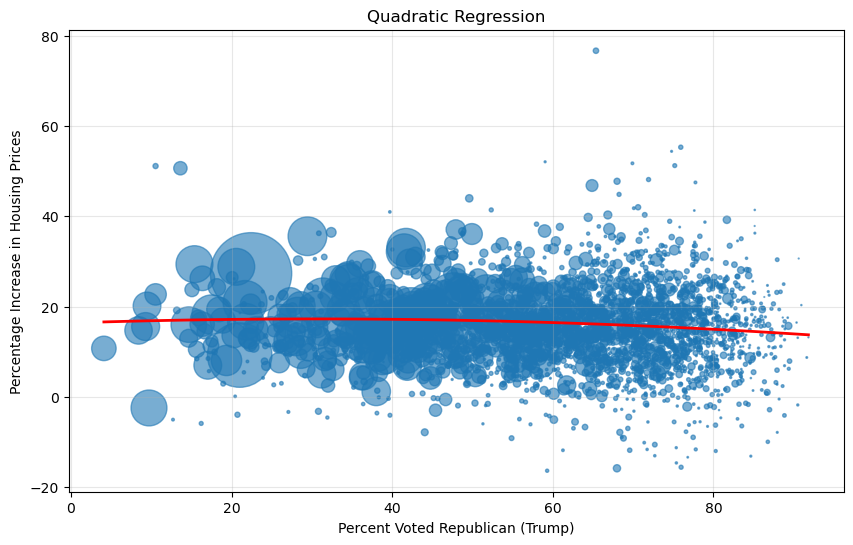

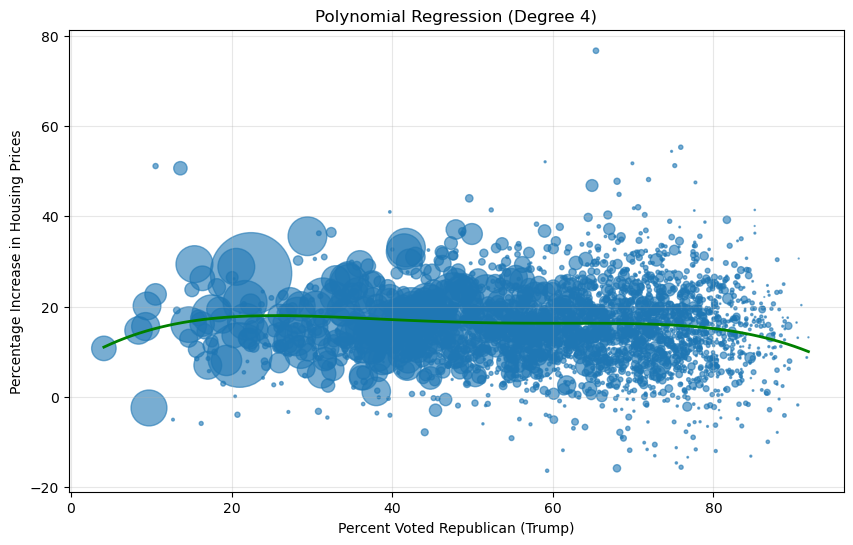

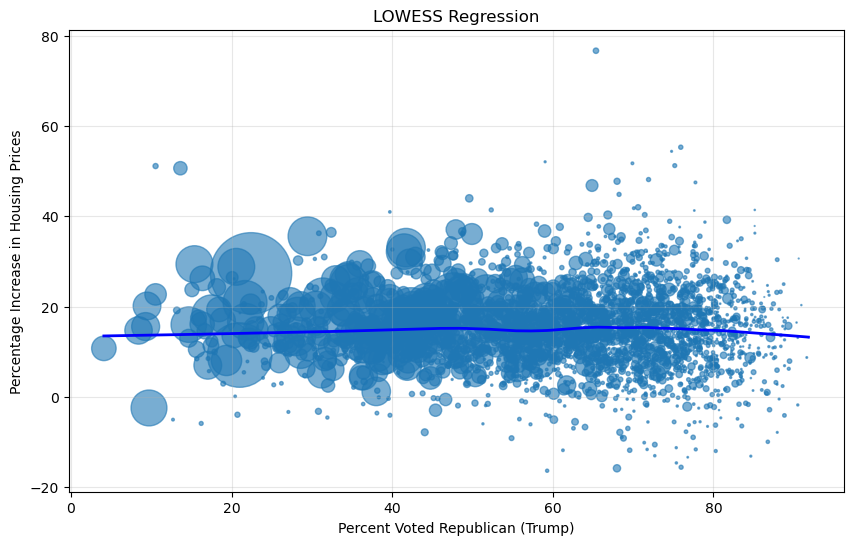

=== Regression Analysis Results ===
Quadratic Regression:
  Weighted R-squared: 0.0064
  Coefficients: [ 0.          0.05775376 -0.00094138]
  Intercept: 16.3933
  Saved to: Images/Votes_Quadratic.png

Polynomial Regression (degree 4):
  Weighted R-squared: 0.0118
  Saved to: Images/Votes_Polynomial.png

LOWESS Regression:
  Weighted R-squared: -0.0758
  (Note: LOWESS doesn't use sample weights directly)
  Saved to: Images/Votes_LOWESS.png


In [73]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess
import os

# Prepare data
X = merged['percent red'].values.reshape(-1, 1)
y = merged['Difference'].values
weights = merged['totalvotes'].values

# Create line points for smooth curves
line_x = np.linspace(merged['percent red'].min(), merged['percent red'].max(), 100)

# Create Images directory
os.makedirs('Images', exist_ok=True)

# Calculate weighted total sum of squares (used for all R-squared calculations)
ss_tot = np.sum(weights * (y - np.average(y, weights=weights)) ** 2)

# 1. Quadratic Regression (Polynomial degree 2)
plt.figure(figsize=(10, 6))
plt.scatter(merged['percent red'], merged['Difference'], 
           alpha=0.6, s=merged['totalvotes']/1000)

# Fit quadratic regression with weights
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
quad_model = LinearRegression()
quad_model.fit(X_poly, y, sample_weight=weights)

# Create quadratic line
line_x_poly = poly_features.transform(line_x.reshape(-1, 1))
quad_line_y = quad_model.predict(line_x_poly)

plt.plot(line_x, quad_line_y, 'r-', linewidth=2)
plt.xlabel('Percent Voted Republican (Trump)')
plt.ylabel('Percentage Increase in Housing Prices')
plt.title('Quadratic Regression')
plt.grid(True, alpha=0.3)

# Calculate weighted R-squared for quadratic
y_pred_quad = quad_model.predict(X_poly)
ss_res_quad = np.sum(weights * (y - y_pred_quad) ** 2)
r_squared_quad = 1 - (ss_res_quad / ss_tot)

# Save quadratic plot
output_path_quad = os.path.join('Images', 'Votes_Quadratic.png')
plt.savefig(output_path_quad, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# 2. Higher-order Polynomial Regression (degree 4)
plt.figure(figsize=(10, 6))
plt.scatter(merged['percent red'], merged['Difference'], 
           alpha=0.6, s=merged['totalvotes']/1000)

# Fit polynomial regression with weights
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=4)),
    ('linear', LinearRegression())
])
poly_model.fit(X, y, linear__sample_weight=weights)

# Create polynomial line
poly_line_y = poly_model.predict(line_x.reshape(-1, 1))

plt.plot(line_x, poly_line_y, 'g-', linewidth=2)
plt.xlabel('Percent Voted Republican (Trump)')
plt.ylabel('Percentage Increase in Housing Prices')
plt.title('Polynomial Regression (Degree 4)')
plt.grid(True, alpha=0.3)

# Calculate weighted R-squared for polynomial
y_pred_poly = poly_model.predict(X)
ss_res_poly = np.sum(weights * (y - y_pred_poly) ** 2)
r_squared_poly = 1 - (ss_res_poly / ss_tot)

# Save polynomial plot
output_path_poly = os.path.join('Images', 'Votes_Polynomial.png')
plt.savefig(output_path_poly, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# 3. LOWESS (Locally Weighted Scatterplot Smoothing)
plt.figure(figsize=(10, 6))
plt.scatter(merged['percent red'], merged['Difference'], 
           alpha=0.6, s=merged['totalvotes']/1000)

# Fit LOWESS (note: statsmodels LOWESS doesn't directly support sample weights)
# We'll use a fraction parameter to control smoothing
lowess_result = lowess(y, merged['percent red'].values, frac=0.3, return_sorted=True)
lowess_x, lowess_y = lowess_result[:, 0], lowess_result[:, 1]

plt.plot(lowess_x, lowess_y, 'b-', linewidth=2)
plt.xlabel('Percent Voted Republican (Trump)')
plt.ylabel('Percentage Increase in Housing Prices')
plt.title('LOWESS Regression')
plt.grid(True, alpha=0.3)

# For LOWESS R-squared, interpolate to get predictions at original X values
lowess_pred = np.interp(merged['percent red'].values, lowess_x, lowess_y)
ss_res_lowess = np.sum(weights * (y - lowess_pred) ** 2)
r_squared_lowess = 1 - (ss_res_lowess / ss_tot)

# Save LOWESS plot
output_path_lowess = os.path.join('Images', 'Votes_LOWESS.png')
plt.savefig(output_path_lowess, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Print results for all three methods
print("=== Regression Analysis Results ===")
print(f"Quadratic Regression:")
print(f"  Weighted R-squared: {r_squared_quad:.4f}")
print(f"  Coefficients: {quad_model.coef_}")
print(f"  Intercept: {quad_model.intercept_:.4f}")
print(f"  Saved to: {output_path_quad}")

print(f"\nPolynomial Regression (degree 4):")
print(f"  Weighted R-squared: {r_squared_poly:.4f}")
print(f"  Saved to: {output_path_poly}")

print(f"\nLOWESS Regression:")
print(f"  Weighted R-squared: {r_squared_lowess:.4f}")
print(f"  (Note: LOWESS doesn't use sample weights directly)")
print(f"  Saved to: {output_path_lowess}")

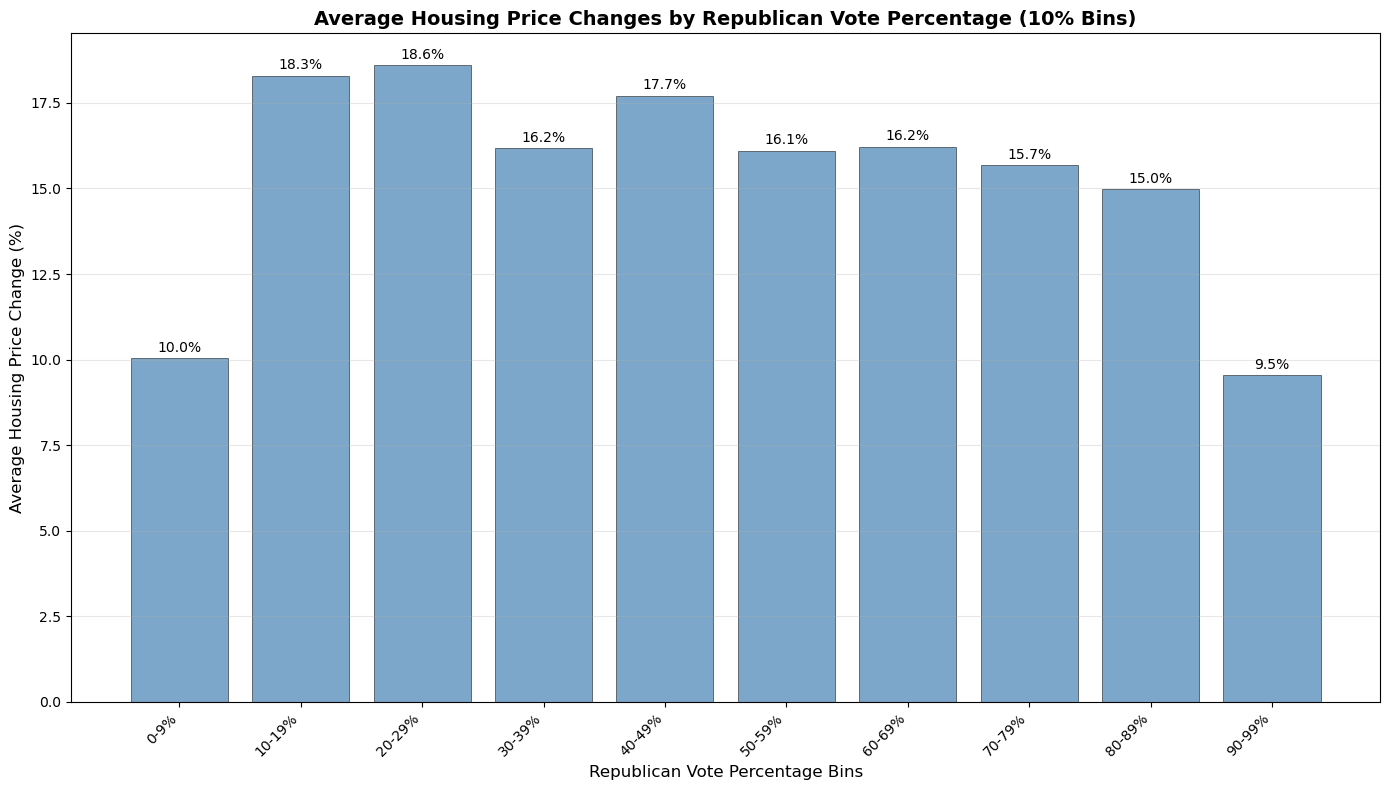

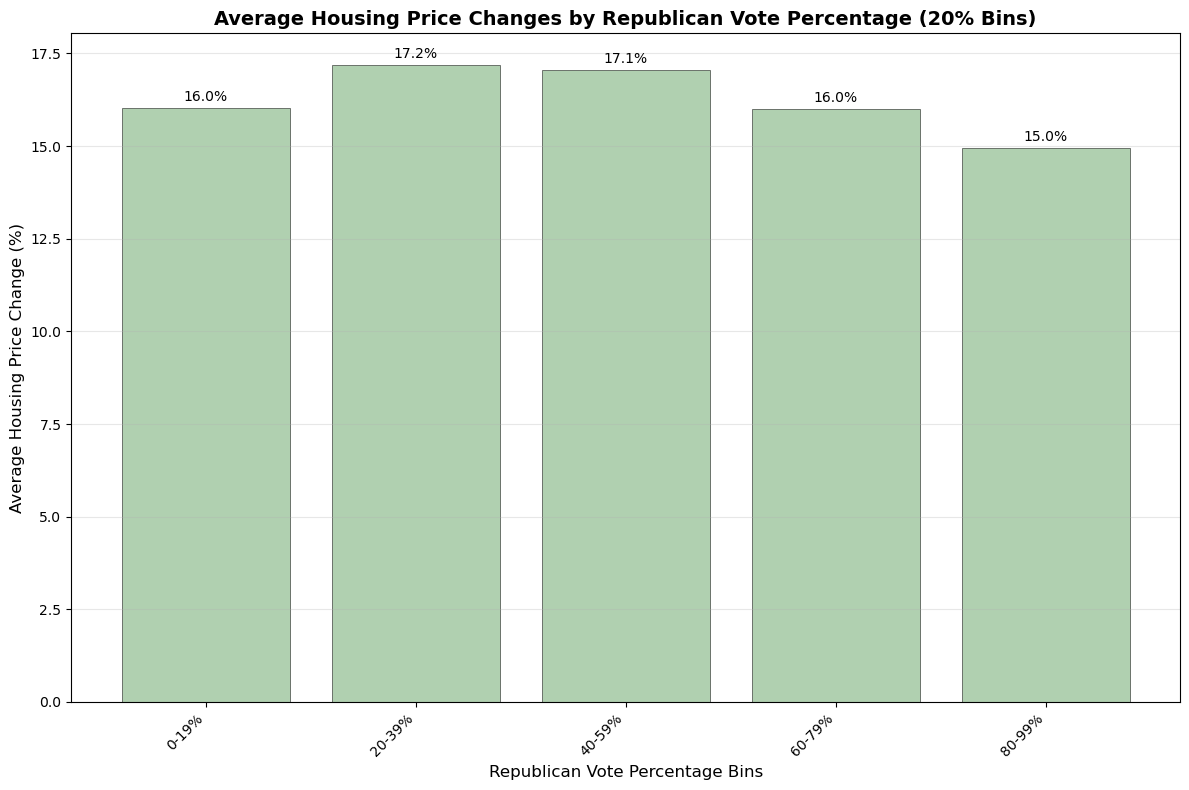

=== Binned Analysis Results ===

10% Bins Summary:
   bin  weighted_avg_change  total_votes  county_count
  0-9%                10.04      2175906             5
10-19%                18.30      5766285            28
20-29%                18.60     16932661            84
30-39%                16.17     23669807           158
40-49%                17.71     33584403           307
50-59%                16.11     22616577           489
60-69%                16.21     17597686           737
70-79%                15.67     11243176           851
80-89%                14.97      2185729           296
90-99%                 9.55         7266             7

Saved 10% bins plot to: Images/Votes_Binned_10percent.png

20% Bins Summary:
   bin  weighted_avg_change  total_votes  county_count
 0-19%                16.03      7942191            33
20-39%                17.18     40602468           242
40-59%                17.07     56200980           796
60-79%                16.00     28840862      

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Create Images directory
os.makedirs('Images', exist_ok=True)

# Function to create bins and calculate weighted averages
def create_binned_analysis(data, bin_size):
    """
    Create bins based on voting percentage and calculate weighted average housing price changes
    """
    # Create bins
    min_vote = data['percent red'].min()
    max_vote = data['percent red'].max()
    
    # Create bin edges
    bin_edges = np.arange(0, 101, bin_size)  # 0 to 100 by bin_size
    bin_labels = [f"{i}-{i+bin_size-1}%" for i in range(0, 100, bin_size)]
    
    # Assign each county to a bin
    data_copy = data.copy()
    data_copy['bin'] = pd.cut(data_copy['percent red'], bins=bin_edges, labels=bin_labels, include_lowest=True)
    
    # Calculate weighted averages for each bin
    bin_stats = []
    for bin_label in bin_labels:
        bin_data = data_copy[data_copy['bin'] == bin_label]
        if len(bin_data) > 0:
            # Weighted average of housing price difference
            weighted_avg = np.average(bin_data['Difference'], weights=bin_data['totalvotes'])
            # Total votes in bin (for reference)
            total_votes = bin_data['totalvotes'].sum()
            # Number of counties in bin
            county_count = len(bin_data)
            
            bin_stats.append({
                'bin': bin_label,
                'weighted_avg_change': weighted_avg,
                'total_votes': total_votes,
                'county_count': county_count
            })
    
    return pd.DataFrame(bin_stats)

# Create 10% bins analysis
bins_10 = create_binned_analysis(merged, 10)

# Create 20% bins analysis  
bins_20 = create_binned_analysis(merged, 20)

# Plot 1: 10% bins (CLEANED - no county counts)
plt.figure(figsize=(14, 8))
bars_10 = plt.bar(range(len(bins_10)), bins_10['weighted_avg_change'], 
                  color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)

plt.xlabel('Republican Vote Percentage Bins', fontsize=12)
plt.ylabel('Average Housing Price Change (%)', fontsize=12)
plt.title('Average Housing Price Changes by Republican Vote Percentage (10% Bins)', fontsize=14, fontweight='bold')
plt.xticks(range(len(bins_10)), bins_10['bin'], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars (ONLY the percentage values)
for i, (bar, value) in enumerate(zip(bars_10, bins_10['weighted_avg_change'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

# REMOVED: County count labels that were causing overlap

plt.tight_layout()
output_path_10 = os.path.join('Images', 'Votes_Binned_10percent.png')
plt.savefig(output_path_10, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Plot 2: 20% bins (CLEANED - no county counts)
plt.figure(figsize=(12, 8))
bars_20 = plt.bar(range(len(bins_20)), bins_20['weighted_avg_change'], 
                  color='darkseagreen', alpha=0.7, edgecolor='black', linewidth=0.5)

plt.xlabel('Republican Vote Percentage Bins', fontsize=12)
plt.ylabel('Average Housing Price Change (%)', fontsize=12)
plt.title('Average Housing Price Changes by Republican Vote Percentage (20% Bins)', fontsize=14, fontweight='bold')
plt.xticks(range(len(bins_20)), bins_20['bin'], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars (ONLY the percentage values)
for i, (bar, value) in enumerate(zip(bars_20, bins_20['weighted_avg_change'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

# REMOVED: County count labels that were causing overlap

plt.tight_layout()
output_path_20 = os.path.join('Images', 'Votes_Binned_20percent.png')
plt.savefig(output_path_20, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Print summary statistics (county counts still available here if needed)
print("=== Binned Analysis Results ===")
print("\n10% Bins Summary:")
print(bins_10.to_string(index=False, float_format='%.2f'))

print(f"\nSaved 10% bins plot to: {output_path_10}")

print("\n20% Bins Summary:")
print(bins_20.to_string(index=False, float_format='%.2f'))

print(f"\nSaved 20% bins plot to: {output_path_20}")

# Additional insights
print("\n=== Key Insights ===")
print(f"10% Bins - Highest price increase: {bins_10.loc[bins_10['weighted_avg_change'].idxmax(), 'bin']} ({bins_10['weighted_avg_change'].max():.1f}%)")
print(f"10% Bins - Lowest price increase: {bins_10.loc[bins_10['weighted_avg_change'].idxmin(), 'bin']} ({bins_10['weighted_avg_change'].min():.1f}%)")
print(f"20% Bins - Highest price increase: {bins_20.loc[bins_20['weighted_avg_change'].idxmax(), 'bin']} ({bins_20['weighted_avg_change'].max():.1f}%)")
print(f"20% Bins - Lowest price increase: {bins_20.loc[bins_20['weighted_avg_change'].idxmin(), 'bin']} ({bins_20['weighted_avg_change'].min():.1f}%)")